## 1. Import Library 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

# Konfigurasi tampilan pandas dan visualisasi
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Data Preparation & Preprocessing


### 2.1 Pemuatan Data dan Pemeriksaan Struktur (Data Loading & Inspection)

In [19]:
# Memuat dataset Life Expectancy dari file CSV
df = pd.read_csv('Day 2 - Life Expectancy Data.csv')

print(f"Ukuran dataset awal: {df.shape[0]} baris dan {df.shape[1]} kolom\n")
display(df.head())

Ukuran dataset awal: 2938 baris dan 22 kolom



,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [20]:
# Informasi ringkas tipe data dan keberadaan nilai non-null pada setiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

### 2.2 Exploratory Data Analysis - EDA


In [21]:
# Memisahkan fitur numerik dan kategorik
num_cols = df.select_dtypes(include=[np.number])
cat_cols = df.select_dtypes(include=['str'])

print("Fitur Kategorik:", cat_cols.columns.tolist())
print(f"Jumlah Fitur Numerik: {num_cols.shape[1]} kolom\n")
display(num_cols.describe())

Fitur Kategorik: ['Country', 'Status']
Jumlah Fitur Numerik: 20 kolom



,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


### 2.3 Analisis Kualitas Data & Handling Missing Values

Jumlah baris sebelum penghapusan target NA : 2938
Jumlah baris setelah penghapusan target NA : 2928


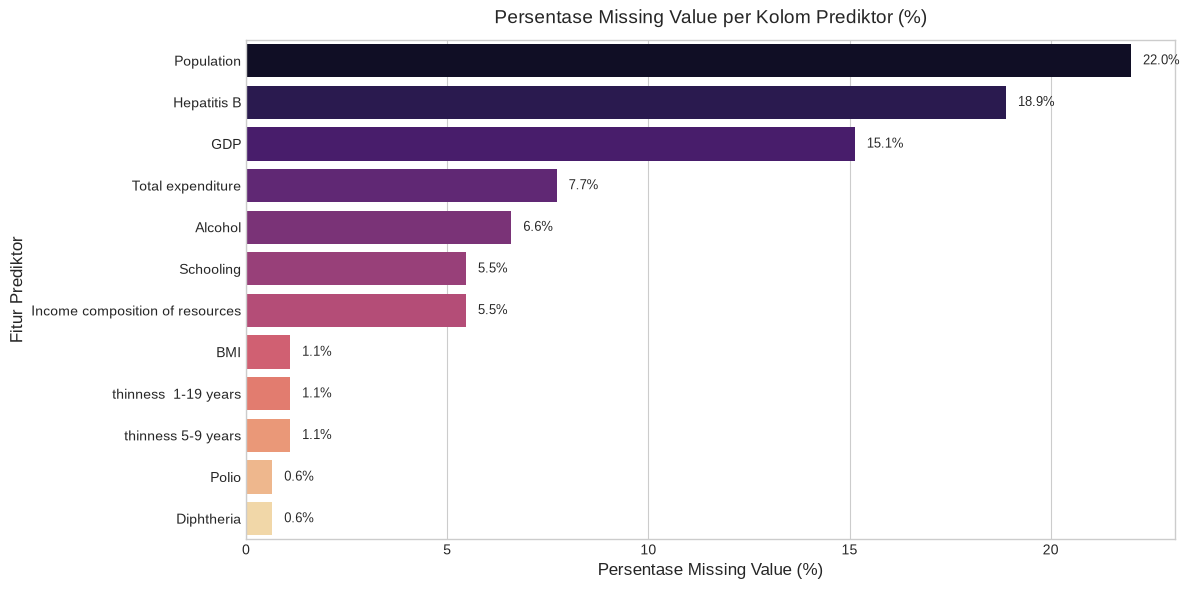

In [22]:
# 1. Merapikan nama kolom dari spasi berlebih
df.columns = df.columns.str.strip()

# 2. Menghapus baris dengan nilai target (Life expectancy) yang kosong
print(f"Jumlah baris sebelum penghapusan target NA : {len(df)}")
df = df.dropna(subset=['Life expectancy'])
print(f"Jumlah baris setelah penghapusan target NA : {len(df)}")

# 3. Menghitung persentase missing value pada fitur prediktor
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Visualisasi persentase missing value
plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index,
    hue=missing_pct.index,
    palette='magma',
    legend=False
)
plt.title('Persentase Missing Value per Kolom Prediktor (%)', fontsize=14, pad=12)
plt.xlabel('Persentase Missing Value (%)', fontsize=12)
plt.ylabel('Fitur Prediktor', fontsize=12)

for idx, val in enumerate(missing_pct.values):
    plt.text(val + 0.3, idx, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Two-Tier Imputation


In [23]:
# Mengurutkan data berdasarkan Negara dan Tahun untuk memastikan urutan kronologis time-series
df = df.sort_values(by=['Country', 'Year'])

# Mengidentifikasi kolom numerik yang memiliki missing value
num_cols_with_na = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).isnull().any()].tolist()
print("Kolom numerik dengan missing values:", num_cols_with_na)

# Tahap 1: Interpolasi linear deret waktu per negara
for col in num_cols_with_na:
    df[col] = df.groupby('Country')[col].transform(lambda group: group.interpolate(method='linear').ffill().bfill())

# Tahap 2: Imputasi nilai sisa menggunakan median kelompok Status (Developing vs Developed)
for col in num_cols_with_na:
    df[col] = df.groupby('Status')[col].transform(lambda group: group.fillna(group.median()))

# Verifikasi akhir integritas data setelah imputasi
total_missing = df.isna().sum().sum()
print(f"Total sisa missing values pada dataset: {total_missing}")
assert total_missing == 0, "Masih terdapat nilai kosong pada dataset!"

Kolom numerik dengan missing values: ['Alcohol', 'Hepatitis B', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
Total sisa missing values pada dataset: 0


### 2.5 Feature Engineering

In [24]:
# 1. Interaksi Pendidikan & Pemanfaatan Sumber Daya
df['HDI Schooling Inteaction'] = df['Income composition of resources'] * df['Schooling']

# 2. Rata-rata Cakupan Imunisasi Dasar
df['Vaccine Coverage Avg'] = (df['Hepatitis B'] + df['Polio'] + df['Diphtheria']) / 3

# 3. Belanja Kesehatan Riil Per Kapita
df['Health Spending Per Capita'] = df['GDP'] * (df['percentage expenditure'] / 100)

# 4. Selisih Kematian Anak Usia 1-5 Tahun
df['Child_Mortality_Gap'] = df['under-five deaths'] - df['infant deaths']

# 5. Rata-rata Prevalensi Kurus/Malnutrisi
df['Thinness_Avg'] = (df['thinness  1-19 years'] + df['thinness 5-9 years']) / 2

# 6. Transformasi Logaritmik untuk Variabel Skewed
df['log_GDP'] = np.log1p(df['GDP'])
df['log_Population'] = np.log1p(df['Population'])
df['log_Measles'] = np.log1p(df['Measles'])

# 7. Menghapus Kolom Mentah Asli dan Variabel Country
df = df.drop(columns=['GDP', 'Population', 'Measles', 'Country'])

print(f"Ukuran dataset setelah Feature Engineering: {df.shape[0]} baris dan {df.shape[1]} kolom\n")
display(df.head())

Ukuran dataset setelah Feature Engineering: 2928 baris dan 26 kolom



,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,HDI Schooling Inteaction,Vaccine Coverage Avg,Health Spending Per Capita,Child_Mortality_Gap,Thinness_Avg,log_GDP,log_Population,log_Measles
15,2000,Developing,54.8,321.0,88,0.01,10.424960,62.0,12.2,122,24.0,8.20,24.0,0.1,2.3,2.5,0.338,5.5,1.8590,36.666667,11.942834,34,2.40,4.749790,12.590508,8.784622
14,2001,Developing,55.3,316.0,88,0.01,10.574728,63.0,12.6,122,35.0,7.80,33.0,0.1,2.1,2.4,0.340,5.9,2.0060,43.666667,12.424986,34,2.25,4.774887,14.902881,9.078294
13,2002,Developing,56.2,3.0,88,0.01,16.887351,64.0,13.0,122,36.0,7.76,36.0,0.1,19.9,2.2,0.341,6.2,2.1142,45.333333,31.722205,34,11.05,5.240932,16.905640,7.818832
12,2003,Developing,56.7,295.0,87,0.01,11.089053,65.0,13.4,122,41.0,8.82,41.0,0.1,19.7,19.9,0.373,6.5,2.4245,49.000000,22.037113,35,19.80,5.296959,14.676226,6.683361
11,2004,Developing,57.0,293.0,87,0.02,15.296066,67.0,13.8,120,5.0,8.79,5.0,0.1,19.5,19.7,0.381,6.8,2.5908,25.666667,33.520007,33,19.60,5.394270,16.998510,6.146329


### 2.6 Data Splitting (Train, Validation, Test Split)
Sesuai instruksi assignment (Poin 2), data dipisahkan menjadi **tiga subset**:
- **Set Pelatihan (Train - 70%):** Digunakan untuk melatih model regresi serta menganalisis korelasi dan multikolinearitas.
- **Set Validasi (Validation - 15%):** Digunakan untuk evaluasi performa model dan verifikasi parameter.
- **Set Pengujian (Test - 15%):** Digunakan untuk evaluasi akhir model terpilih pada data baru yang belum pernah dilihat sama sekali (*unseen holdout data*).

In [25]:
# Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns='Life expectancy')
y = df['Life expectancy']

# Tahap 1: Pisahkan 70% Train dan 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=6767)

# Tahap 2: Pisahkan 30% Temporary menjadi 15% Validation dan 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=6767)

print(f"Total Baris Dataset        : {len(df)}")
print(f"Set Pelatihan (Train)      : {len(X_train)} baris ({len(X_train)/len(df)*100:.1f}%)")
print(f"Set Validasi (Validation)  : {len(X_val)} baris ({len(X_val)/len(df)*100:.1f}%)")
print(f"Set Pengujian (Test)       : {len(X_test)} baris ({len(X_test)/len(df)*100:.1f}%)")

Total Baris Dataset        : 2928
Set Pelatihan (Train)      : 2049 baris (70.0%)
Set Validasi (Validation)  : 439 baris (15.0%)
Set Pengujian (Test)       : 440 baris (15.0%)


### 2.7 Categorical Encoding
Variabel kategorik `Status` memiliki dua tingkat nilai: `'Developing'` dan `'Developed'`. Kita melakukan *binary encoding* secara manual menggunakan mapping:
- `'Developing'` $\rightarrow 0$
- `'Developed'` $\rightarrow 1$

In [26]:
status_map = {
    'Developing': 0,
    'Developed': 1
}

X_train_encode = X_train.copy()
X_val_encode = X_val.copy()
X_test_encode = X_test.copy()

X_train_encode['Status'] = X_train['Status'].map(status_map)
X_val_encode['Status'] = X_val['Status'].map(status_map)
X_test_encode['Status'] = X_test['Status'].map(status_map)

print("Encoding kolom Status berhasil diterapkan pada set Train, Validation, dan Test.")
display(X_train_encode.head())

Encoding kolom Status berhasil diterapkan pada set Train, Validation, dan Test.


,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,HDI Schooling Inteaction,Vaccine Coverage Avg,Health Spending Per Capita,Child_Mortality_Gap,Thinness_Avg,log_GDP,log_Population,log_Measles
2678,2002,0,19.0,4,1.17,262.818494,93.0,49.7,5,96.0,5.32,96.0,0.1,6.5,6.4,0.662,13.3,8.8046,95.000000,6167.282232,1,6.45,7.761146,16.104435,4.595120
1901,2007,0,388.0,542,9.55,104.474644,42.0,2.4,863,54.0,4.47,42.0,5.2,12.3,12.3,0.477,9.1,4.3407,46.000000,1187.698729,321,12.30,7.036878,16.499386,7.868637
1574,2011,0,441.0,32,1.23,13.776175,97.0,18.0,50,97.0,11.67,97.0,11.2,6.7,6.6,0.444,10.6,4.7064,97.000000,70.551296,18,6.65,6.240520,16.564550,3.295837
285,2002,0,283.0,25,1.23,40.488152,15.0,19.2,40,76.0,4.27,75.0,2.1,9.3,9.2,0.407,7.3,2.9711,55.333333,169.523317,15,9.25,6.039537,15.802754,7.370860
740,2012,1,76.0,0,9.26,928.417079,94.0,57.7,0,94.0,1.98,94.0,0.1,1.1,0.9,0.922,18.4,16.9648,94.000000,54382.225341,0,1.00,8.675652,15.536771,1.098612


## 3. Analisis Korelasi dan Seleksi Fitur

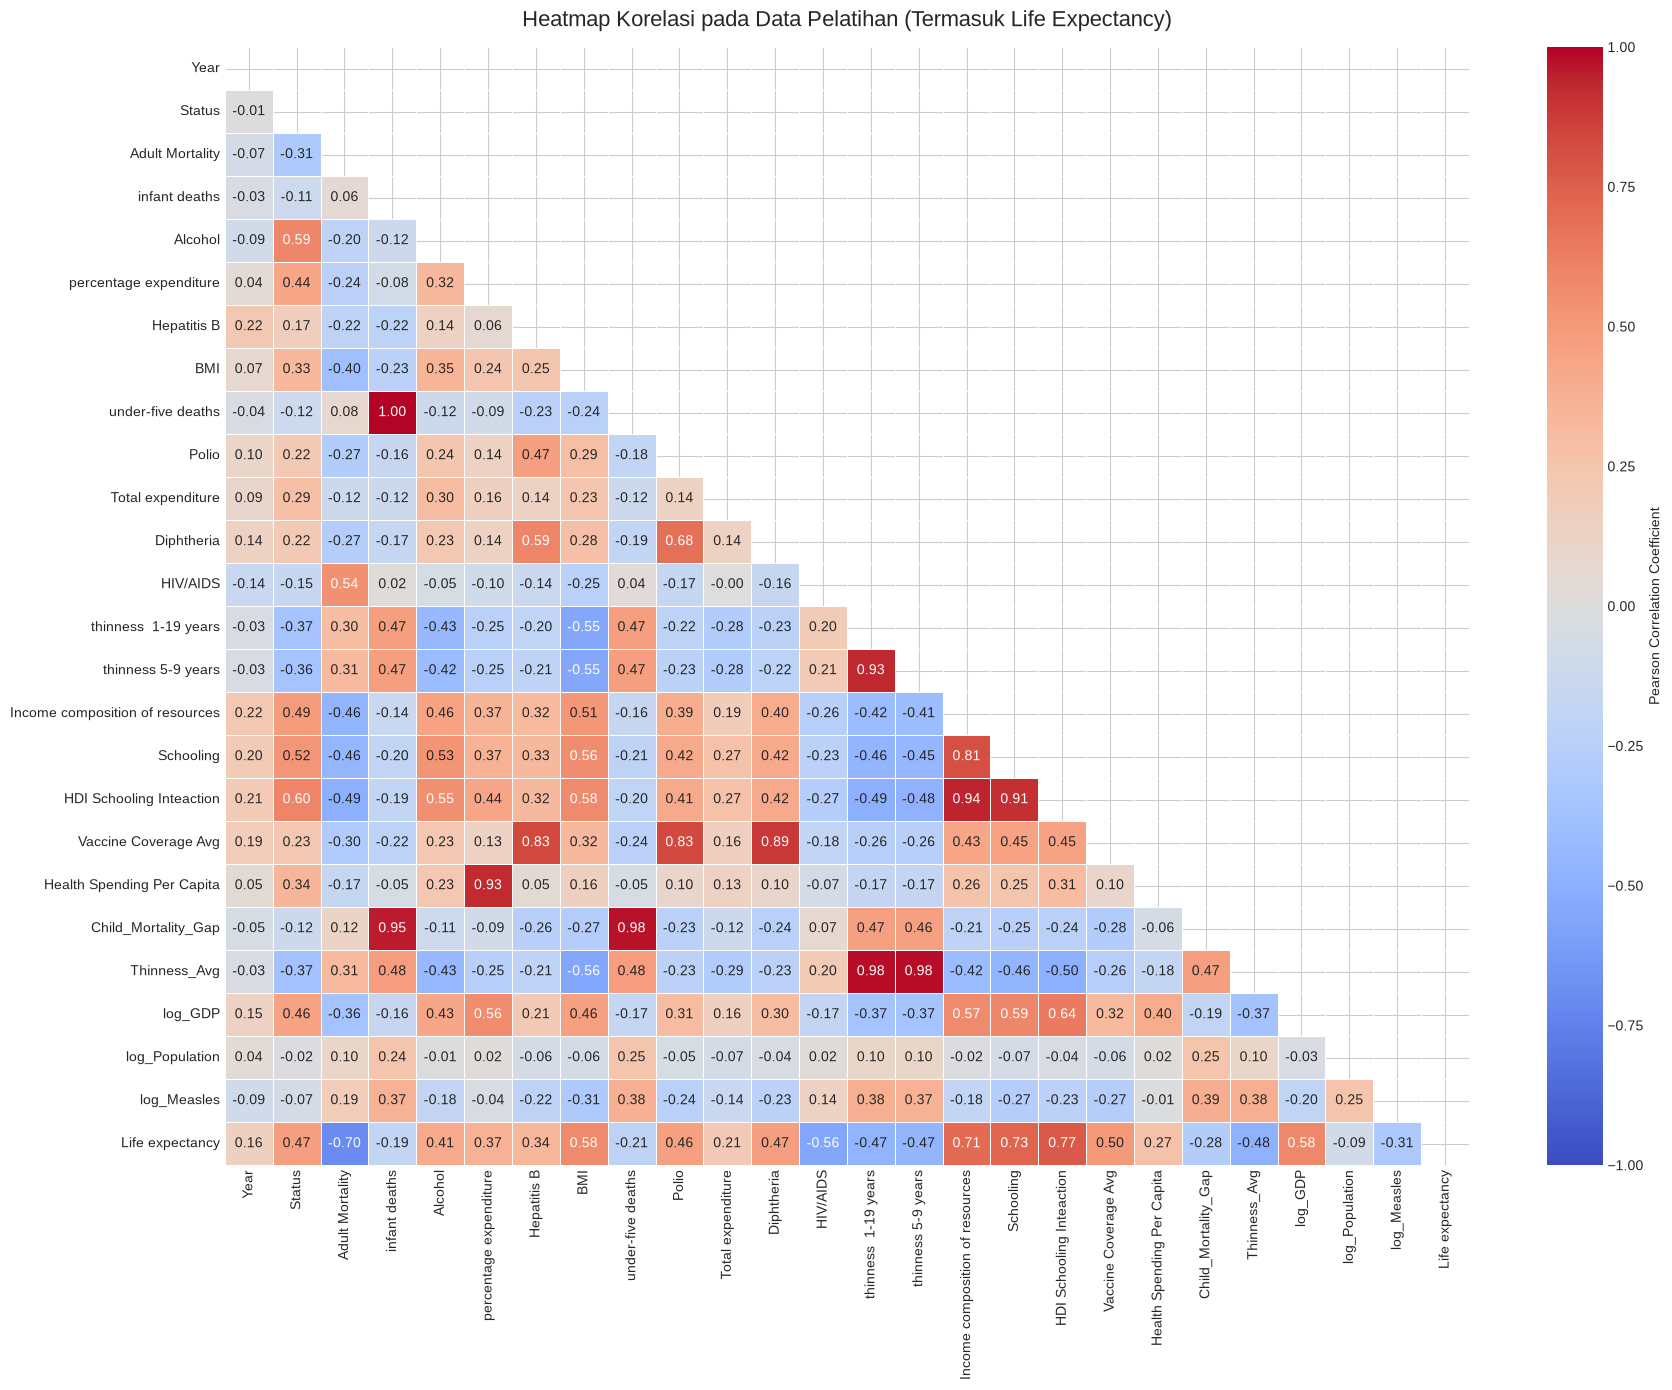

In [27]:
# Menggabungkan X_train_encode dan y_train untuk analisis korelasi (khusus data latih)
train_corr_data = pd.concat([X_train_encode, y_train], axis=1)
corr_matrix = train_corr_data.corr()

# Visualisasi Heatmap Korelasi Lengkap
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Heatmap Korelasi pada Data Pelatihan (Termasuk Life Expectancy)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

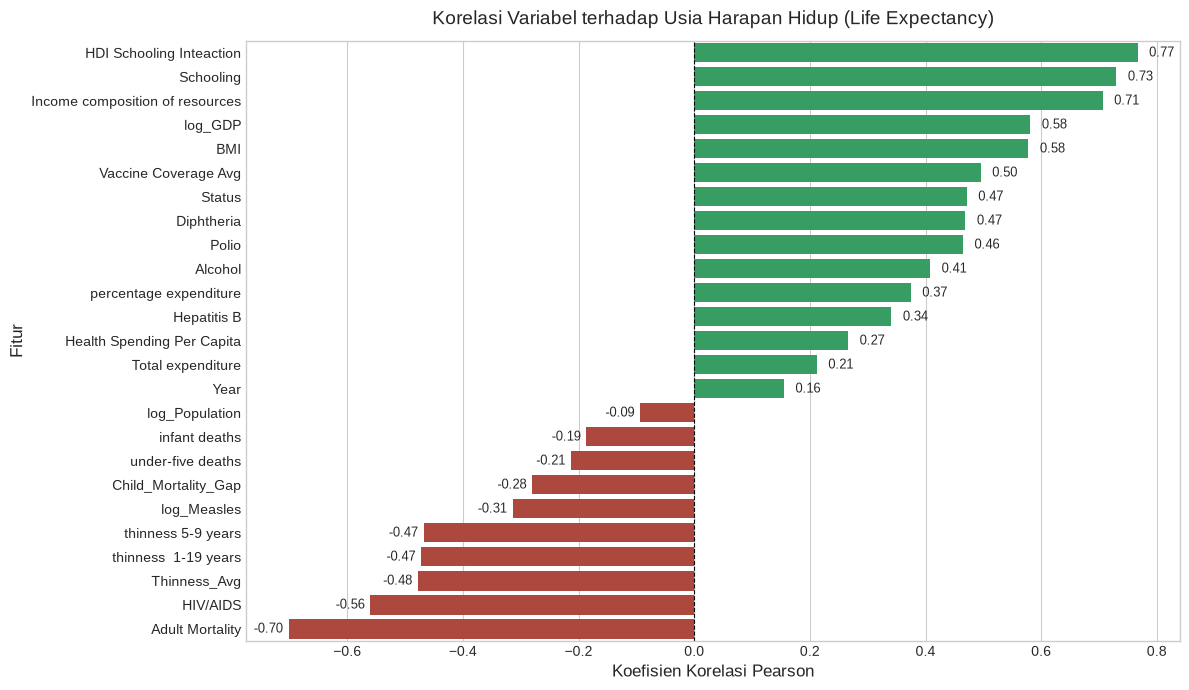

In [28]:
# Visualisasi Korelasi Setiap Fitur terhadap Target Usia Harapan Hidup (Life Expectancy)
target_corr = corr_matrix['Life expectancy'].drop('Life expectancy').sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = ['#27ae60' if val > 0 else '#c0392b' for val in target_corr.values]
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette=colors, legend=False)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Korelasi Variabel terhadap Usia Harapan Hidup (Life Expectancy)', fontsize=14, pad=12)
plt.xlabel('Koefisien Korelasi Pearson', fontsize=12)
plt.ylabel('Fitur', fontsize=12)

for idx, val in enumerate(target_corr.values):
    plt.text(val + (0.02 if val >= 0 else -0.06), idx, f"{val:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.1 Deteksi Multikolinearitas & Perhitungan Variance Inflation Factor (VIF)

In [29]:
# Fungsi untuk menghitung VIF untuk setiap variabel independen
def calculate_vif(df_features):
    vif_data = []
    for col in df_features.columns:
        X_other = df_features.drop(columns=[col])
        y_col = df_features[col]
        lr_temp = LinearRegression().fit(X_other, y_col)
        r2 = lr_temp.score(X_other, y_col)
        vif = 1.0 / (1.0 - r2) if (1.0 - r2) > 1e-10 else np.inf
        vif_data.append(vif)
    vif_df = pd.DataFrame({'Fitur': df_features.columns, 'VIF': vif_data})
    return vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True)

# Menghitung VIF sebelum seleksi fitur
vif_before = calculate_vif(X_train_encode)
print("VIF Value Sebelum Feature Selection")
display(vif_before)

VIF Value Sebelum Feature Selection


,Fitur,VIF
0,under-five deaths,2.712916e+09
1,infant deaths,2.362270e+08
2,Vaccine Coverage Avg,1.494114e+08
3,Child_Mortality_Gap,1.564580e+07
4,Hepatitis B,2.355902e+06
5,Diphtheria,5.690856e+05
6,Polio,1.689313e+05
7,Thinness_Avg,5.441147e+04
8,thinness 5-9 years,1.381987e+01
9,thinness 1-19 years,1.367503e+01


### 3.2 Seleksi Fitur untuk Mengeliminasi Multikolinearitas

In [30]:
# Kolom redundan yang dieliminasi untuk mengatasi multikolinearitas
cols_to_drop = [
    'infant deaths',
    'Child_Mortality_Gap',
    'Hepatitis B',
    'Polio',
    'Diphtheria',
    'thinness  1-19 years',
    'thinness 5-9 years',
    'percentage expenditure'
]

X_train_sel = X_train_encode.drop(columns=cols_to_drop)
X_val_sel = X_val_encode.drop(columns=cols_to_drop)
X_test_sel = X_test_encode.drop(columns=cols_to_drop)

# Menghitung ulang VIF setelah seleksi fitur
vif_after = calculate_vif(X_train_sel)
print("VIF Value Setelah Feature Selection")
display(vif_after)

VIF Value Setelah Feature Selection


,Fitur,VIF
0,HDI Schooling Inteaction,7.658700
1,Schooling,6.236737
2,Income composition of resources,6.017064
3,Thinness_Avg,2.111082
4,Status,1.938747
5,log_GDP,1.930126
6,BMI,1.852865
7,Adult Mortality,1.827282
8,Alcohol,1.746617
9,under-five deaths,1.502208


### 3.3 Standarisasi Nilai Numerik (StandardScaler)

In [31]:
# Inisialisasi StandardScaler
ss = StandardScaler()

# Fit dan transform pada data pelatihan
X_train_scaled = pd.DataFrame(
    ss.fit_transform(X_train_sel),
    columns=X_train_sel.columns,
    index=X_train_sel.index
)

# Transform pada data validasi dan data pengujian
X_val_scaled = pd.DataFrame(
    ss.transform(X_val_sel),
    columns=X_val_sel.columns,
    index=X_val_sel.index
)

X_test_scaled = pd.DataFrame(
    ss.transform(X_test_sel),
    columns=X_test_sel.columns,
    index=X_test_sel.index
)

display(X_train_scaled.head())

,Year,Status,Adult Mortality,Alcohol,BMI,under-five deaths,Total expenditure,HIV/AIDS,Income composition of resources,Schooling,HDI Schooling Inteaction,Vaccine Coverage Avg,Health Spending Per Capita,Thinness_Avg,log_GDP,log_Population,log_Measles
2678,-1.181632,-0.458560,-1.194403,-0.830603,0.568631,-0.232858,-0.228084,-0.325384,0.151308,0.392494,0.167352,0.678346,-0.206975,0.361029,0.177191,0.900542,0.386458
1901,-0.097852,-0.458560,1.790839,1.223893,-1.834096,5.140981,-0.569967,0.664466,-0.751604,-0.885399,-0.930363,-1.628451,-0.210707,1.699721,-0.231985,1.066425,1.394620
1574,0.769171,-0.458560,2.219614,-0.815893,-1.041654,0.048987,2.325990,1.828995,-0.912664,-0.429008,-0.840434,0.772501,-0.211544,0.406796,-0.681889,1.093795,-0.013688
285,-1.181632,-0.458560,0.941380,-0.815893,-0.980696,-0.013645,-0.650411,0.062792,-1.093247,-1.433067,-1.267161,-1.189061,-0.211470,1.001771,-0.795435,0.773832,1.241318
740,0.985927,2.180738,-0.733268,1.152794,0.975012,-0.264174,-1.571486,-0.325384,1.420266,1.944221,2.174023,0.631269,-0.170840,-0.886129,0.693843,0.662116,-0.690379


## 4. Model Training & Evaluasi Data Validasi

In [32]:
# Inisialisasi dan pelatihan model Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Prediksi pada Train Set dan Validation Set
y_train_pred_lr = lr.predict(X_train_scaled)
y_val_pred_lr = lr.predict(X_val_scaled)

# Evaluasi Metrik pada Training Set
r2_train = r2_score(y_train, y_train_pred_lr)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
mae_train = mean_absolute_error(y_train, y_train_pred_lr)

# Evaluasi Metrik pada Validation Set
r2_val = r2_score(y_val, y_val_pred_lr)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
mae_val = mean_absolute_error(y_val, y_val_pred_lr)

# Tabel Ringkasan Evaluasi Model Linear Regression
val_results = pd.DataFrame({
    'Metrik Evaluasi': ['R2 Score', 'RMSE (Tahun)', 'MAE (Tahun)'],
    'Set Pelatihan (Train)': [r2_train, rmse_train, mae_train],
    'Set Validasi (Validation)': [r2_val, rmse_val, mae_val]
})

print("Evaluasi Model Linear Regression Pada Data Val")
display(val_results.round(4))

Evaluasi Model Linear Regression Pada Data Val


,Metrik Evaluasi,Set Pelatihan (Train),Set Validasi (Validation)
0,R2 Score,0.8108,0.8321
1,RMSE (Tahun),4.1256,4.0250
2,MAE (Tahun),3.0808,3.0815


### Pembahasan Hasil Evaluasi pada Set Validasi:
- **$R^2$ Score:** Model Linear Regression berhasil menjelaskan sekitar **83.21%** varians usia harapan hidup pada set validasi ($R^2 = 0.8321$). Performa ini sangat dekat dengan performa pada data train ($R^2 = 0.8251$), yang mengindikasikan bahwa model memiliki generalisasi yang sangat stabil tanpa gejala *overfitting* maupun *underfitting*.
- **RMSE dan MAE:** Rata-rata selisih absolut prediksi pada set validasi adalah **3.08 tahun** ($	ext{MAE} = 3.0815$), dengan nilai RMSE sebesar **4.02 tahun** ($	ext{RMSE} = 4.0250$). Angka error ini tergolong rendah untuk memprediksi rentang angka harapan hidup global (yang berkisar antara 36 hingga 89 tahun).

## 5. Interpretasi Model

Tabel Koefisien Linear Regression


,Fitur,Koefisien
0,HDI Schooling Inteaction,2.6749
1,Schooling,1.1902
2,Vaccine Coverage Avg,1.1357
3,log_GDP,0.9258
4,BMI,0.6819
5,Health Spending Per Capita,0.2146
6,Status,0.1210
7,Total expenditure,0.0511
8,Alcohol,-0.0272
9,under-five deaths,-0.0829


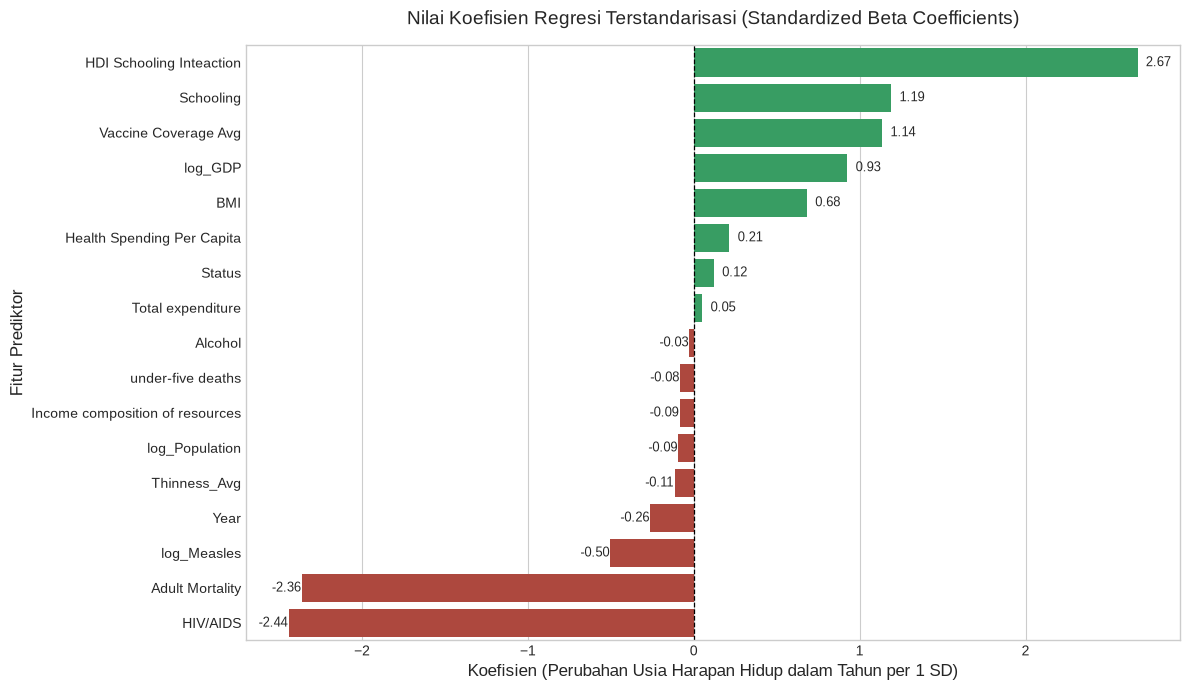

In [33]:
# Membuat DataFrame Koefisien Regresi Terurut
coef_df = pd.DataFrame({
    'Fitur': X_train_scaled.columns,
    'Koefisien': lr.coef_
}).sort_values(by='Koefisien', ascending=False).reset_index(drop=True)

print("Tabel Koefisien Linear Regression")
display(coef_df.round(4))

# Visualisasi Horizontal Barplot Koefisien
plt.figure(figsize=(12, 7))
bar_colors = ['#27ae60' if c > 0 else '#c0392b' for c in coef_df['Koefisien']]
sns.barplot(x='Koefisien', y='Fitur', data=coef_df, hue='Fitur', palette=bar_colors, legend=False)
plt.axvline(0, color='black', linestyle='--', linewidth=0.9)
plt.title('Nilai Koefisien Regresi Terstandarisasi (Standardized Beta Coefficients)', fontsize=14, pad=15)
plt.xlabel('Koefisien (Perubahan Usia Harapan Hidup dalam Tahun per 1 SD)', fontsize=12)
plt.ylabel('Fitur Prediktor', fontsize=12)

for idx, row in coef_df.iterrows():
    val = row['Koefisien']
    plt.text(val + (0.05 if val >= 0 else -0.18), idx, f"{val:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Evaluasi Model Akhir pada Data Test

Hasil Evaluasi Akhir Model Linear Regression Pada Data Test


,Metrik Evaluasi,Nilai Performa
0,Test R2 Score,0.8152
1,Test RMSE (Tahun),4.0324
2,Test MAE (Tahun),2.9606


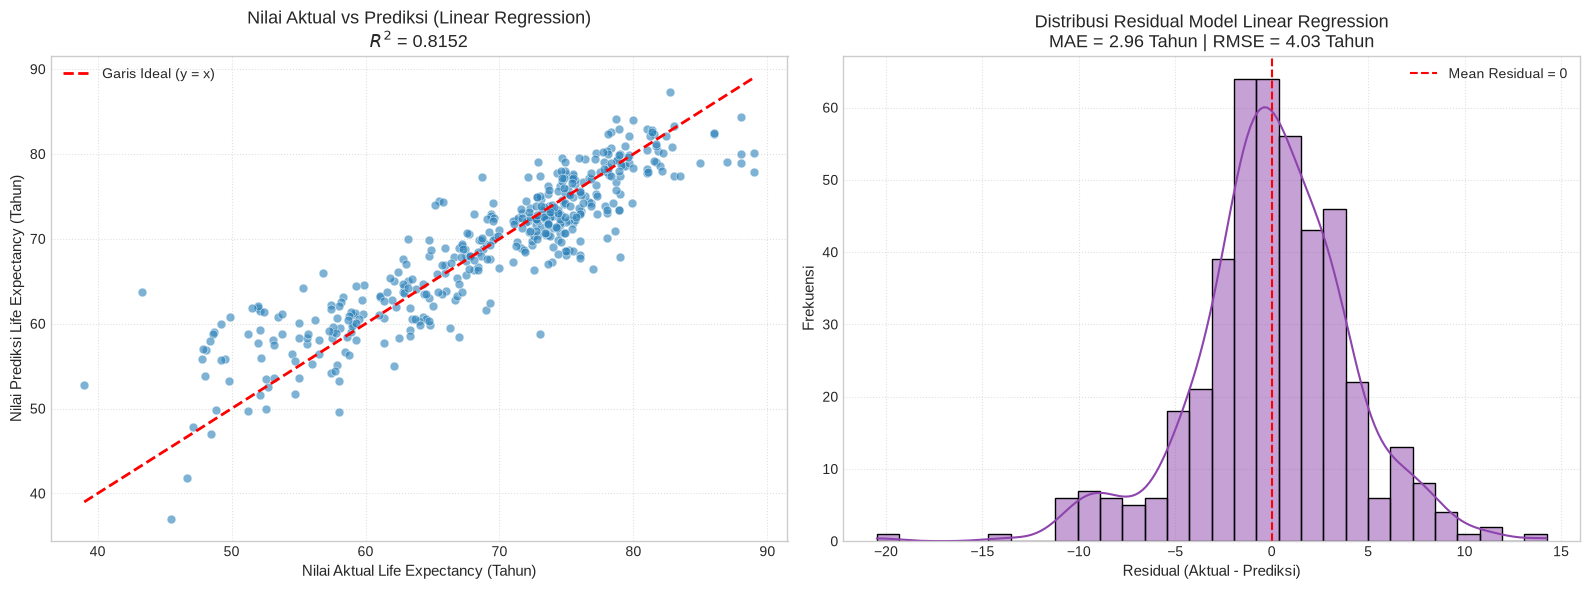

In [34]:
# Prediksi pada Test Set menggunakan Linear Regression
y_test_pred_lr = lr.predict(X_test_scaled)

# Metrik Evaluasi Test Set
test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

# Tabel Ringkasan Evaluasi Test Set
test_summary = pd.DataFrame({
    'Metrik Evaluasi': ['Test R2 Score', 'Test RMSE (Tahun)', 'Test MAE (Tahun)'],
    'Nilai Performa': [test_r2_lr, test_rmse_lr, test_mae_lr]
})

print("Hasil Evaluasi Akhir Model Linear Regression Pada Data Test")
display(test_summary.round(4))

# Visualisasi Performa: Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Nilai Aktual vs Nilai Prediksi
sns.scatterplot(x=y_test, y=y_test_pred_lr, ax=axes[0], color='#2980b9', alpha=0.6, s=40)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Garis Ideal (y = x)')
axes[0].set_title(f'Nilai Aktual vs Prediksi (Linear Regression)\n$R^2$ = {test_r2_lr:.4f}', fontsize=13)
axes[0].set_xlabel('Nilai Aktual Life Expectancy (Tahun)', fontsize=11)
axes[0].set_ylabel('Nilai Prediksi Life Expectancy (Tahun)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Distribusi Residual (Error)
residuals_lr = y_test - y_test_pred_lr
sns.histplot(residuals_lr, kde=True, ax=axes[1], color='#8e44ad', bins=30)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5, label='Mean Residual = 0')
axes[1].set_title(f'Distribusi Residual Model Linear Regression\nMAE = {test_mae_lr:.2f} Tahun | RMSE = {test_rmse_lr:.2f} Tahun', fontsize=13)
axes[1].set_xlabel('Residual (Aktual - Prediksi)', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 6.1 Rekomendasi Kebijakan Kesehatan Masyarakat

Berdasarkan hasil analisis data, berikut langkah strategis yang perlu diambil untuk meningkatkan usia harapan hidup masyarakat:

#### 1. Prioritas Utama: Penanganan HIV/AIDS dan Pencegahan Campak
- **Fakta di Lapangan:** Penularan HIV/AIDS dan wabah campak terbukti menjadi ancaman paling besar yang memangkas usia hidup masyarakat.
- **Rencana Aksi:**
  - Membuka layanan tes HIV gratis dan rahasia di seluruh puskesmas serta klinik kesehatan terdekat.
  - Memastikan obat penekan virus HIV (ARV) selalu tersedia gratis tanpa alur birokrasi yang berbelit.
  - Menggencarkan edukasi publik untuk menghapus stigma negatif agar pasien tidak takut memeriksakan diri.
  - Menyiapkan tim tanggap darurat untuk vaksinasi cepat jika muncul tanda-tanda lonjakan kasus campak di suatu wilayah.

#### 2. Pencegahan Kematian Dini pada Usia Produktif
- **Fakta di Lapangan:** Tingginya angka kematian pada usia dewasa secara drastis menurunkan rata-rata umur harapan hidup.
- **Rencana Aksi:**
  - Mengadakan cek kesehatan berkala secara massal (tensi darah, gula darah, dan kolesterol) mulai dari usia 30 tahun ke atas.
  - Menaikkan tarif cukai rokok dan minuman keras, serta memperketat izin iklan untuk membatasi konsumsi zat berbahaya.
  - Mempertegas aturan keselamatan kerja di pabrik atau proyek bangunan serta memperbaiki keamanan lalu lintas guna menekan korban kecelakaan kerja dan jalan raya.

#### 3. Perluasan Akses Pendidikan dan Edukasi Pola Hidup Sehat
- **Fakta di Lapangan:** Warga yang mengenyam pendidikan lebih tinggi terbukti memiliki peluang hidup lebih lama dan lebih sehat.
- **Rencana Aksi:**
  - Menjamin pendidikan gratis hingga jenjang SMA dan mempermudah akses beasiswa bagi siswa dari keluarga prasejahtera.
  - Memasukkan materi pola makan bergizi, kebersihan diri, dan pencegahan penyakit ke dalam pelajaran sekolah sejak tingkat dasar.

#### 4. Pemerataan Vaksinasi Dasar untuk Anak
- **Fakta di Lapangan:** Kelengkapan imunisasi sejak bayi berkontribusi nyata dalam memperpanjang usia hidup generasi muda.
- **Rencana Aksi:**
  - Memperbaiki fasilitas penyimpanan vaksin bersuhu dingin di puskesmas pelosok agar vaksin tidak cepat rusak selama proses distribusi.
  - Menggerakkan kader posyandu dan tokoh masyarakat setempat untuk meyakinkan orang tua yang masih ragu mengimunisasi anaknya.

#### 5. Pengentasan Gizi Kurang dan Masalah Sanitasi
- **Fakta di Lapangan:** Balita yang kekurangan gizi dan sering sakit-sakitan memiliki ketahanan tubuh rendah, yang berujung pada tingginya angka kematian anak.
- **Rencana Aksi:**
  - Membagikan makanan tambahan bergizi berbasis pangan lokal, khususnya sumber protein hewani, untuk anak bertubuh sangat kurus dan ibu hamil.
  - Membangun akses air minum bersih dan jamban sehat di permukiman padat guna memutus penularan penyakit diare berulang pada balita.